In [15]:
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt

In [16]:
# Set base directory
dir_path = "/global/scratch/users/yougsanghvi"

# Construct full path to ERA5 CSV
era5_filepath = os.path.join(
    dir_path,
    "data", "merged", "USA",
    "USA_adm2_1968_2004_monthly.dta"
)

# Load the ERA5 dataset
era5_df = pd.read_stata(era5_filepath)

# Define paths for usa county shapefile
usa_county_dir = os.path.join(dir_path, "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)

era5full_filepath = os.path.join(
    dir_path,
    "data", "climatedata", "USA",
    "usa_area_era5_temp_average_1968_2004_polynomial_5_area_crop_weights.csv"
)

# Load the ERA5 dataset
era5full_df = pd.read_csv(era5full_filepath)

# Loading in county shapefile
usa_counties = gpd.read_file(usa_county_path)


In [17]:

# Preview the data
print(era5full_df.head())

   year     month  poly_id     order_1       order_2        order_3  \
0  1968  month_01    66010  809.525712  21148.066612  552689.640160   
1  1968  month_02    66010  745.377742  19162.975018  492783.926998   
2  1968  month_03    66010  810.887864  21213.814140  555054.625154   
3  1968  month_04    66010  788.264914  20714.948921  544447.993773   
4  1968  month_05    66010  832.136596  22344.346350  600179.878807   

        order_4       order_5  
0  1.444981e+07  3.779311e+08  
1  1.267524e+07  3.261076e+08  
2  1.452486e+07  3.801433e+08  
3  1.431166e+07  3.762570e+08  
4  1.612637e+07  4.334445e+08  


In [18]:
# Filter era5_df to year between 2000 and 2004 inclusive
era5_filtered = era5_df[(era5_df['year'] >= 2000) & (era5_df['year'] <= 2004)]
era5full_filtered = era5full_df[(era5full_df['year'] >= 2000) & (era5full_df['year'] <= 2004)]

# Get unique counties by 'fips'
unique_counties = era5_filtered['fips'].nunique()

print(f"Unique counties (fips) from 2000-2004: {unique_counties}")


Unique counties (fips) from 2000-2004: 529


In [19]:
era5full_filtered

,year,month,poly_id,order_1,order_2,order_3,order_4,order_5
1239552,2000,month_01,66010,824.063503,21914.412624,582997.955191,1.551566e+07,4.130827e+08
1239553,2000,month_02,66010,776.330163,20786.377729,556665.570920,1.491051e+07,3.994590e+08
1239554,2000,month_03,66010,835.801745,22537.678005,607825.276604,1.639500e+07,4.422894e+08
1239555,2000,month_04,66010,820.620232,22448.910401,614158.416733,1.680342e+07,4.597768e+08
1239556,2000,month_05,66010,844.319105,23005.267664,627081.626868,1.710005e+07,4.664950e+08
...,...,...,...,...,...,...,...,...
1433227,2004,month_08,78020,854.386327,23552.728446,649413.658565,1.790993e+07,4.940346e+08
1433228,2004,month_09,78020,815.764846,22192.504189,604007.843506,1.644641e+07,4.480115e+08
1433229,2004,month_10,78020,834.427332,22468.910965,605261.471726,1.631069e+07,4.397144e+08
1433230,2004,month_11,78020,779.677264,20269.333771,527104.891361,1.371165e+07,3.567952e+08


In [ ]:

# Step 2: Prepare shapefile
usa_counties['GEOID'] = usa_counties['GEOID'].astype(int)

# Merge shapefile with avg temperature data
merged = usa_counties.merge(avg_poly1_by_county, left_on='GEOID', right_on='fips', how='left')

# Step 3: Crop to mainland USA (approx bounding box)
# Mainland bounding box: [long_min, lat_min, long_max, lat_max]
bbox = (-125, 24, -66, 50)
merged_mainland = merged.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 9))
merged_mainland.plot(
    column='tavg_poly1_aw',
    cmap='coolwarm',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    ax=ax
)
ax.set_title('Average tavg_poly1_aw by County (2000–2004)', fontsize=16)
ax.axis('off')
plt.show()

"\n# Step 3: Compute the average (mean) of order_1_div30 by county\norder_avg = era5full_filtered_copy.groupby('poly_id')['order_1_div30'].mean().reset_index()\n\n# Step 4: Convert GEOID to int in the county shapefile\nusa_counties['GEOID'] = usa_counties['GEOID'].astype(int)\n\n# Step 5: Merge the shapefile with the order_1 data\nmerged = usa_counties.merge(order_avg, left_on='GEOID', right_on='poly_id', how='left')\n\n# Step 6: Crop to mainland USA using bounding box\nbbox = (-125, 24, -66, 50)\nmerged_mainland = merged.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]\n\n# Step 7: Plot\nfig, ax = plt.subplots(figsize=(14, 9))\nmerged_mainland.plot(\n    column='order_1_div30',\n    cmap='coolwarm',\n    edgecolor='black',\n    linewidth=0.3,\n    legend=True,\n    ax=ax\n)\nax.set_title('Mean of order_1 / 30 by County (Mainland US)', fontsize=16)\nax.axis('off')\nplt.show()\n"

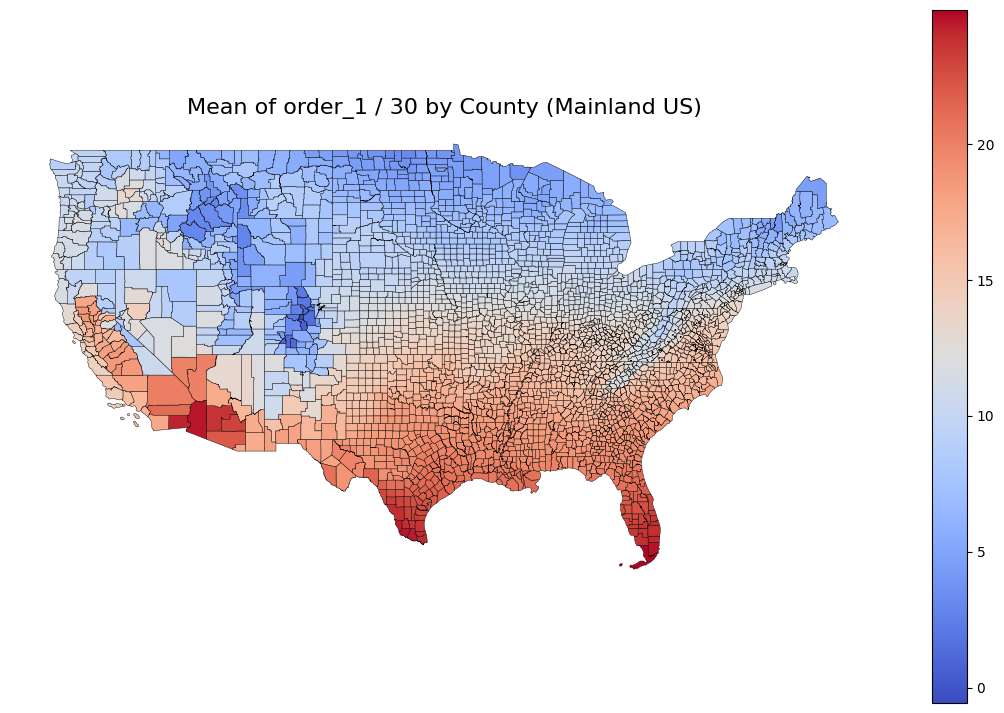

In [26]:

# Step 3: Compute the average (mean) of order_1_div30 by county
order_avg = era5full_filtered_copy.groupby('poly_id')['order_1_div30'].mean().reset_index()

# Step 4: Convert GEOID to int in the county shapefile
usa_counties['GEOID'] = usa_counties['GEOID'].astype(int)

# Step 5: Merge the shapefile with the order_1 data
merged = usa_counties.merge(order_avg, left_on='GEOID', right_on='poly_id', how='left')

# Step 6: Crop to mainland USA using bounding box
bbox = (-125, 24, -66, 50)
merged_mainland = merged.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Step 7: Plot
fig, ax = plt.subplots(figsize=(14, 9))
merged_mainland.plot(
    column='order_1_div30',
    cmap='coolwarm',
    edgecolor='black',
    linewidth=0.3,
    legend=True,
    ax=ax
)
ax.set_title('Mean of order_1 / 30 by County (Mainland US)', fontsize=16)
ax.axis('off')
plt.show()


In [ ]:
order_avg

,year,month,poly_id,order_1,order_2,order_3,order_4,order_5,order_1_div30
1239552,2000,month_01,66010,824.063503,21914.412624,582997.955191,1.551566e+07,4.130827e+08,27.468783
1239553,2000,month_02,66010,776.330163,20786.377729,556665.570920,1.491051e+07,3.994590e+08,25.877672
1239554,2000,month_03,66010,835.801745,22537.678005,607825.276604,1.639500e+07,4.422894e+08,27.860058
1239555,2000,month_04,66010,820.620232,22448.910401,614158.416733,1.680342e+07,4.597768e+08,27.354008
1239556,2000,month_05,66010,844.319105,23005.267664,627081.626868,1.710005e+07,4.664950e+08,28.143970
...,...,...,...,...,...,...,...,...,...
1433227,2004,month_08,78020,854.386327,23552.728446,649413.658565,1.790993e+07,4.940346e+08,28.479544
1433228,2004,month_09,78020,815.764846,22192.504189,604007.843506,1.644641e+07,4.480115e+08,27.192162
1433229,2004,month_10,78020,834.427332,22468.910965,605261.471726,1.631069e+07,4.397144e+08,27.814244
1433230,2004,month_11,78020,779.677264,20269.333771,527104.891361,1.371165e+07,3.567952e+08,25.989242


In [ ]:

avg_poly1_by_county = era5full_filtered.groupby('fips')['tavg_poly1_aw'].mean().reset_index()


# Step 2: Prepare shapefile
usa_counties['GEOID'] = usa_counties['GEOID'].astype(int)

# Merge shapefile with avg temperature data
merged = usa_counties.merge(avg_poly1_by_county, left_on='GEOID', right_on='fips', how='left')

# Step 3: Crop to mainland USA (approx bounding box)
# Mainland bounding box: [long_min, lat_min, long_max, lat_max]
bbox = (-125, 24, -66, 50)
merged_mainland = merged.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 9))
merged_mainland.plot(
    column='tavg_poly1_aw',
    cmap='coolwarm',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    ax=ax
)
ax.set_title('Average tavg_poly1_aw by County (2000–2004)', fontsize=16)
ax.axis('off')
plt.show()

In [30]:
import xarray as xr
import os
import matplotlib.pyplot as plt

# Step 1: Define path and years
data_dir = "/global/scratch/users/yougsanghvi/era5_daily_by_year"
years = range(2000, 2005)  # 2000–2004

# Step 2: Read and concatenate NetCDFs along time dimension
datasets = []
for year in years:
    file_path = os.path.join(data_dir, f"era5_daily_mean_{year}.nc")
    ds = xr.open_dataset(file_path)
    datasets.append(ds)

# Combine into one dataset along time
combined_ds = xr.concat(datasets, dim="time")

# Step 3: Average across time (days) to get mean for each grid cell
mean_ds = combined_ds.mean(dim="time")

# Step 4: Plot temperature (assuming variable is named 't2m' for 2m temperature)
# If variable name is different (e.g. 'temperature'), update below

temp_var = 't2m' if 't2m' in mean_ds.data_vars else list(mean_ds.data_vars.keys())[0]

# Convert from Kelvin to Celsius (optional)
mean_temp_celsius = mean_ds[temp_var] - 273.15



/tmp/ipykernel_140954/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_140954/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_140954/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_140954/640799054.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta 

In [31]:

# Define mainland USA bounding box
lon_min, lon_max = -125, -66
lat_min, lat_max = 24, 50

# Subset to mainland USA
mean_temp_celsius_usa = mean_temp_celsius.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)  # Note: latitude is usually descending, so max first then min
)

# Plot zoomed map
mean_temp_celsius_usa.plot(
    cmap="coolwarm",
    figsize=(10, 8),
    cbar_kwargs={'label': 'Mean Temp (°C)'}
)
plt.title("ERA5 Daily Mean Temperature (2000–2004 Average) — Mainland USA")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

TypeError: No numeric data to plot.